## River discharge

This notebook treats The river discharge outputs from Lebreton et al. (Lebreton, L., van der Zwet, J., Damsteeg, JW. et al. River plastic emissions to the world’s oceans. Nat Commun 8, 15611 (2017). https://doi.org/10.1038/ncomms15611) and from Meijer et al., (Lourens J. J. Meijer et al., More than 1000 rivers account for 80% of global riverine plastic emissions into the ocean.Sci. Adv.7,eaaz5803(2021). DOI:10.1126/sciadv.aaz5803). Both datasets provide different results, thus they are both evaluated.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs  
import cartopy.feature as cfeature
import numpy as np
from shapely import area
from geopy.distance import geodesic
import geopandas as gpd
from shapely.geometry import Point
from scipy.spatial import cKDTree
from sklearn.preprocessing import MinMaxScaler
from scipy import stats

## Lebreton

In [2]:
# https://doi.org/10.6084/m9.figshare.4725541 #
folder = pd.read_csv("inputs\\PlasticRiverInputs.csv", sep=",")
folder


,X,Y,i_mid,i_low,i_high,i_mid_jan,i_low_jan,i_high_jan,i_mid_feb,i_low_feb,...,runoff_may,runoff_jun,runoff_jul,runoff_aug,runoff_sep,runoff_oct,runoff_nov,runoff_dec,mpw,area
0,9.812500,37.329167,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,21753.300,22500000.0
1,9.387500,37.254167,0.117503,0.046447,0.431570,0.008847,0.003387,0.033584,0.025464,0.010425,...,0.492051,0.275476,0.172272,0.075899,0.067729,0.176044,0.588417,0.466081,506114.000,95100000.0
2,9.804167,37.237500,0.004653,0.001518,0.021067,0.000364,0.000116,0.001692,0.000750,0.000250,...,0.518217,0.321421,0.236187,0.135462,0.101813,0.223936,0.821796,0.500808,56294.600,33500000.0
3,9.229167,37.220833,0.163098,0.065719,0.586740,0.019418,0.007780,0.070142,0.041209,0.017347,...,0.689654,0.422857,0.275328,0.182635,0.184765,0.335541,1.101117,0.927117,349409.000,99200000.0
4,9.254167,37.220833,0.038200,0.014144,0.150693,0.003528,0.001281,0.014193,0.008848,0.003407,...,0.545944,0.315671,0.200378,0.105010,0.099647,0.219543,0.728243,0.591818,199000.000,39700000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40755,-68.145833,-55.470833,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.561928,0.804659,0.873344,0.877528,0.677601,0.422401,0.293490,0.241877,13.095,34500000.0
40756,-68.345833,-55.479167,0.000000,0.000000,0.000001,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.824595,1.010224,1.052044,0.983748,0.893081,0.573895,0.382559,0.308781,26.555,27800000.0
40757,-68.095833,-55.529167,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.561927,0.804659,0.873342,0.877530,0.677603,0.422402,0.293488,0.241878,18.163,26700000.0
40758,-68.229167,-55.570833,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.561929,0.804659,0.873342,0.877527,0.677603,0.422399,0.293490,0.241877,10.763,16000000.0


In [3]:
folder["runoff_mean"] = folder[['runoff_jan', 'runoff_feb', 'runoff_mar', 'runoff_apr', 'runoff_may',	'runoff_jun',	'runoff_jul',	'runoff_aug',	'runoff_sep',	'runoff_oct',	'runoff_nov',	'runoff_dec']].mean(axis=1)

In [4]:
data = pd.read_csv('..\\0.1 MP abundance data collection\FINAL gridded concentrations.csv')
data.head()

,Shape,Lat_center,Lon_center,MEAN MP stock (g/m2) in 2021,MP_std,n_points
0,Fibers,-74.5,163.5,3.353587e-08,NaN,1
1,Fibers,-74.5,164.5,4.351279e-07,1.732525e-07,10
2,Fibers,-42.5,147.5,1.041953e-02,NaN,1
3,Fibers,-38.5,144.5,1.395096e-02,NaN,1
4,Fibers,-35.5,138.5,9.684738e-03,NaN,1


In [5]:
latitudes_folder  = np.array(folder["Y"], dtype=float)
longitudes_folder = np.array(folder["X"], dtype=float)
mpw = np.array(folder["mpw"], dtype=float)
RiverInput = np.array(folder["i_mid"], dtype=float)
catchment_area = np.array(folder["area"], dtype=float)
runoff = np.array(folder["runoff_mean"], dtype=float)

discharge_folder = list(zip(latitudes_folder, longitudes_folder, mpw, RiverInput, catchment_area, runoff))

lats_folder   = [p[0] for p in discharge_folder]
lons_folder   = [p[1] for p in discharge_folder]
# Format: (latitude, longitude, "Label")

# ──────────────────────────────────────────────────────────────────────────────
latitudes_data  = np.array(data["Lat_center"], dtype=float)
longitudes_data = np.array(data["Lon_center"], dtype=float)

points_data = list(zip(latitudes_data, longitudes_data))
# Format: (latitude, longitude, "Label")

lats_data   = [p[0] for p in points_data]
lons_data   = [p[1] for p in points_data]



### Plot

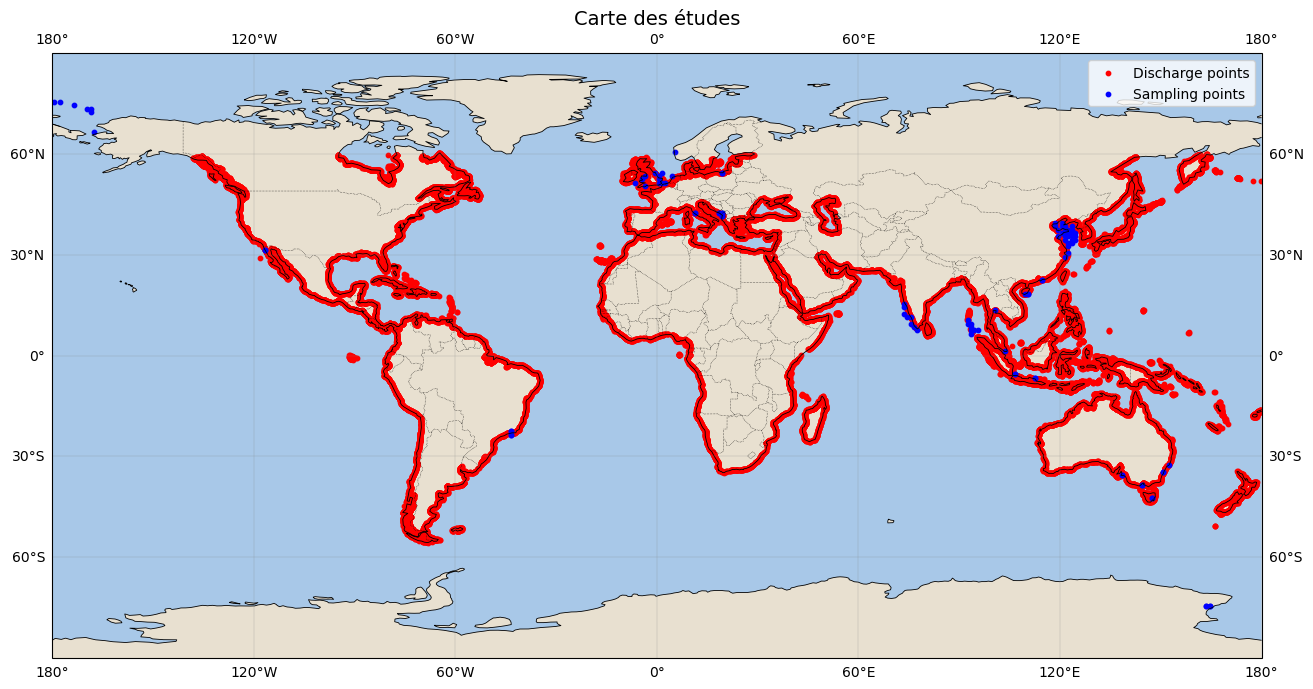

In [6]:

fig = plt.figure(figsize=(14, 7))
ax  = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

ax.set_global()
ax.add_feature(cfeature.LAND,       facecolor="#e8e0d0")
ax.add_feature(cfeature.OCEAN,      facecolor="#a8c8e8")
ax.add_feature(cfeature.COASTLINE,  linewidth=0.6)
ax.add_feature(cfeature.BORDERS,    linewidth=0.4, linestyle=":")
ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5)

ax.scatter(lons_folder, lats_folder, s=10, color="red", zorder=1, transform=ccrs.PlateCarree(), label = 'Discharge points')
ax.scatter(lons_data, lats_data, s=10, color="blue", zorder=1, transform=ccrs.PlateCarree(), label = 'Sampling points')

plt.title("Carte des études", fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

### Data treatment

In [7]:
## Data treatment ## 

def compute_distances(lat, lon, lats, lons):
    """Computes distances in km using the Haversine formula"""
    R = 6378
    lat1, lon1, lat2, lon2 = np.radians(lat), np.radians(lon), np.radians(lats), np.radians(lons)
    dLat = (lat2-lat1)
    dLon = (lon2-lon1)
    d = 2*R*np.arcsin(np.sqrt((np.sin(dLat/2))**2 + np.cos(lat1) * np.cos(lat2) * (np.sin(dLon/2))**2))
    return d

points_arr = np.array(discharge_folder, dtype=object)
coords     = np.array([(p[0], p[1]) for p in discharge_folder], dtype=float)

In [8]:
def nearest_discharge(method, lat, lon, coords, points_array):
    """ Returns distance from sapling point to nearest river discharge point and its associated values. 4 ways to search for nearest point exist:
    nearest point - finds the smallest distance
    sum of 5 nearests - finds 5 smallest distances and does the sum of values for each columns, mean distance is considered
    100 km radius - finds the smallest distance and then sums all municipalities in a 100 km radius around the nearest one
    50 km radius - finds the smallest distance and then sums all municipalities in a 50 km radius around the nearest one
    Mean value over multiple river discharges were found to be not good indicators.
    """

    distances = compute_distances(lat, lon, coords[:, 0], coords[:, 1])
    distances = distances[np.isfinite(distances)]
    
    # Find closest point
    if method == "nearest point":
        idx_nearest = np.argmin(distances)
        nearest = points_array[idx_nearest]
        nearest = np.array(nearest, dtype=object)
        min_distance = distances[idx_nearest]
        return (min_distance, nearest[2:])  # Return distance and parameters of nearest point
    
    if method == "sum of 5 nearests":
        idx_smallest_five = np.argpartition(distances, 5)[:5] # rearranges the indices so that the 5 smallest values are guaranteed to be in the first 5 positions of the result 
        nearby = points_array[idx_smallest_five]
        min_distances = distances[idx_smallest_five]
        nearby = np.nansum(nearby, axis=0)
        return (np.nanmean(min_distances, axis=0), nearby[2:])
    
    if method == "100 km radius":
        idx_nearest = np.argmin(distances)
        nearest = points_array[idx_nearest]
        min_distance = distances[idx_nearest]
        # Vectorized distances from nearest point to all points
        distances_from_nearest = compute_distances(nearest[0], nearest[1], coords[:, 0], coords[:, 1])

        # All points within 100 km
        mask = distances_from_nearest <= 100
        nearby = points_array[mask]
        nearby = np.nansum(nearby, axis=0) + nearest
        return (min_distance, nearby[2:])
    
    if method == "50 km radius":
        idx_nearest = np.argmin(distances)
        nearest = points_array[idx_nearest]
        min_distance = distances[idx_nearest]
        # Vectorized distances from nearest point to all points
        distances_from_nearest = compute_distances(nearest[0], nearest[1], coords[:, 0], coords[:, 1])

        # All points within 50 km
        mask = distances_from_nearest <= 50
        nearby = points_array[mask]
        nearby = np.nansum(nearby, axis=0) + nearest

        return (min_distance, nearby[2:])

In [9]:
latitudes_folder, longitudes_folder, mpw, RiverInput, catchment_area, runoff

(array([ 37.32916667,  37.25416667,  37.2375    , ..., -55.52916667,
        -55.57083333, -55.62083333], shape=(40760,)),
 array([  9.8125    ,   9.3875    ,   9.80416667, ..., -68.09583333,
        -68.22916667, -68.1375    ], shape=(40760,)),
 array([2.17533e+04, 5.06114e+05, 5.62946e+04, ..., 1.81630e+01,
        1.07630e+01, 9.75400e+00], shape=(40760,)),
 array([0.      , 0.117503, 0.004653, ..., 0.      , 0.      , 0.      ],
       shape=(40760,)),
 array([22500000., 95100000., 33500000., ..., 26700000., 16000000.,
        14600000.], shape=(40760,)),
 array([0.        , 0.459006  , 0.5044985 , ..., 0.48576033, 0.48575975,
        0.48575983], shape=(40760,)))

In [10]:
column_names = ['MMPW (kg/yr)','River plastic input (tonnes/yr)', 'Catchment area (m2)', 'Runoff in catchment (mm/day)']

result_np = []
result_sum5 = []
result_100km = []
result_50km = []

for lat, lon in zip(lats_data, lons_data):
    output = nearest_discharge(method = "nearest point",lat = lat, lon = lon, coords = coords, points_array = points_arr)
    result_np.append(output)
    output = nearest_discharge(method = "sum of 5 nearests",lat = lat, lon = lon, coords = coords, points_array = points_arr)
    result_sum5.append(output)
    output = nearest_discharge(method = "100 km radius",lat = lat, lon = lon, coords = coords, points_array = points_arr)
    result_100km.append(output)
    output = nearest_discharge(method = "50 km radius",lat = lat, lon = lon, coords = coords, points_array = points_arr)
    result_50km.append(output)

df_np = pd.DataFrame(result_np[i] for i in range(len(result_np)))
df_np = pd.concat([df_np.drop(1, axis=1),df_np[1].apply(pd.Series)], axis=1)
df_np.columns = ['Distance Lebreton nearest_point'] + [f"{column_names[i]} nearest_point" for i in range(0, len(df_np.columns)-1)]


df_sum5 = pd.DataFrame(result_sum5[i] for i in range(len(result_sum5)))
df_sum5 = pd.concat([df_sum5.drop(1, axis=1),df_sum5[1].apply(pd.Series)], axis=1)
df_sum5.columns = ['Distance Lebreton sum5'] + [f"{column_names[i]} sum5" for i in range(0, len(df_np.columns)-1)]

df_100km = pd.DataFrame(result_100km[i] for i in range(len(result_100km)))
df_100km = pd.concat([df_100km.drop(1, axis=1),df_100km[1].apply(pd.Series)], axis=1)
df_100km.columns = ['Distance Lebreton 100km'] + [f"{column_names[i]} 100km" for i in range(0, len(df_np.columns)-1)]
df_50km = pd.DataFrame(result_50km[i] for i in range(len(result_50km)))
df_50km = pd.concat([df_50km.drop(1, axis=1),df_50km[1].apply(pd.Series)], axis=1)
df_50km.columns = ['Distance Lebreton 50km'] + [f"{column_names[i]} 50km" for i in range(0, len(df_np.columns)-1)]

In [12]:
output = pd.concat([df_np, df_sum5, df_100km, df_50km], axis=1)
output

,Distance Lebreton nearest_point,MMPW (kg/yr) nearest_point,River plastic input (tonnes/yr) nearest_point,Catchment area (m2) nearest_point,Runoff in catchment (mm/day) nearest_point,Distance Lebreton sum5,MMPW (kg/yr) sum5,River plastic input (tonnes/yr) sum5,Catchment area (m2) sum5,Runoff in catchment (mm/day) sum5,Distance Lebreton 100km,MMPW (kg/yr) 100km,River plastic input (tonnes/yr) 100km,Catchment area (m2) 100km,Runoff in catchment (mm/day) 100km,Distance Lebreton 50km,MMPW (kg/yr) 50km,River plastic input (tonnes/yr) 50km,Catchment area (m2) 50km,Runoff in catchment (mm/day) 50km
0,2640.734514,0.000,0.000000,19000000.0,0.000000,2807.957920,12.836,0.000000,9.240000e+07,3.174868,2640.734514,0.000,0.000000,7.340000e+07,0.000000,2640.734514,0.000,0.000000,7.340000e+07,0.000000
1,2638.936689,0.000,0.000000,19000000.0,0.000000,2805.786622,12.836,0.000000,9.240000e+07,3.174868,2638.936689,0.000,0.000000,7.340000e+07,0.000000,2638.936689,0.000,0.000000,7.340000e+07,0.000000
2,31.227377,429.787,0.000000,49200000.0,0.076412,31.731969,18950.637,0.000017,1.516300e+09,0.373212,31.227377,120832.112,0.008843,1.694270e+10,8.903312,31.227377,90936.305,0.006362,1.178320e+10,3.116365
3,23.704461,374.059,0.000002,51900000.0,0.520411,26.499776,167019.928,0.000747,9.303000e+09,1.432821,23.704461,2535249.304,0.170047,2.060420e+10,18.274640,23.704461,237428.831,0.000866,1.065720e+10,5.812940
4,12.766229,2426.090,0.000000,123100000.0,0.007698,14.648496,4438.961,0.000001,5.321000e+08,0.435380,12.766229,820920.566,0.031761,7.867882e+11,4.032034,12.766229,157152.288,0.000265,3.664300e+09,1.794757
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,1870.812276,23.166,0.000000,13700000.0,1.052598,1884.019907,3140.787,0.000184,1.757700e+09,4.741668,1870.812276,8253.452,0.000530,4.593300e+09,19.755488,1870.812276,4235.718,0.000235,2.394100e+09,9.993699
100,1895.608415,23.166,0.000000,13700000.0,1.052598,1908.867753,3140.787,0.000184,1.757700e+09,4.741668,1895.608415,8253.452,0.000530,4.593300e+09,19.755488,1895.608415,4235.718,0.000235,2.394100e+09,9.993699
101,1858.374545,23.166,0.000000,13700000.0,1.052598,1871.082569,3140.787,0.000184,1.757700e+09,4.741668,1858.374545,8253.452,0.000530,4.593300e+09,19.755488,1858.374545,4235.718,0.000235,2.394100e+09,9.993699
102,1846.271633,23.166,0.000000,13700000.0,1.052598,1858.212715,3140.787,0.000184,1.757700e+09,4.741668,1846.271633,8253.452,0.000530,4.593300e+09,19.755488,1846.271633,4235.718,0.000235,2.394100e+09,9.993699


In [13]:
output_divided = output.copy()

# Remove infinities and zero values from distance denominators before normalization
keys = ['nearest_point', 'sum5', '100km', '50km']
for key in keys:
    dist = output_divided[f'Distance Lebreton {key}'].replace({0: np.nan})
    output_divided[f'Input/Distance Lebreton {key}'] = output_divided[f'River plastic input (tonnes/yr) {key}']/dist

    ar = output_divided[f'Catchment area (m2) {key}'].replace({0: np.nan})
    output_divided[f'MMPW/Area {key}'] = output_divided[f'MMPW (kg/yr) {key}']/ar


In [14]:
output_divided.keys()

Index(['Distance Lebreton nearest_point', 'MMPW (kg/yr) nearest_point',
       'River plastic input (tonnes/yr) nearest_point',
       'Catchment area (m2) nearest_point',
       'Runoff in catchment (mm/day) nearest_point', 'Distance Lebreton sum5',
       'MMPW (kg/yr) sum5', 'River plastic input (tonnes/yr) sum5',
       'Catchment area (m2) sum5', 'Runoff in catchment (mm/day) sum5',
       'Distance Lebreton 100km', 'MMPW (kg/yr) 100km',
       'River plastic input (tonnes/yr) 100km', 'Catchment area (m2) 100km',
       'Runoff in catchment (mm/day) 100km', 'Distance Lebreton 50km',
       'MMPW (kg/yr) 50km', 'River plastic input (tonnes/yr) 50km',
       'Catchment area (m2) 50km', 'Runoff in catchment (mm/day) 50km',
       'Input/Distance Lebreton nearest_point', 'MMPW/Area nearest_point',
       'Input/Distance Lebreton sum5', 'MMPW/Area sum5',
       'Input/Distance Lebreton 100km', 'MMPW/Area 100km',
       'Input/Distance Lebreton 50km', 'MMPW/Area 50km'],
      dtype='str

In [15]:
data_points_expended = pd.concat([data, output_divided], axis = 1)
data_points_expended.to_csv('outputs\River Discharge Lebreton dataset.csv',index=False)

# Statistics

In [16]:
parameters = output_divided.keys()

n = len(parameters)
if n % 2 == 0: n = n//2
else: n = n//2 + 1


In [17]:
# Normalize data for statistics
data_points_copy = data_points_expended.copy()
cols_to_normalize = [
                     'MEAN MP stock (g/m2) in 2021',
                     *parameters]

scaler = MinMaxScaler()
data_points_copy[cols_to_normalize] = scaler.fit_transform(data_points_copy[cols_to_normalize])

# Divide fibers from fragments
data_points_fib = data_points_copy[data_points_copy["Shape"] == "Fibers"]
data_points_frg = data_points_copy[data_points_copy["Shape"] == "Fragments"]

In [18]:
spearman_results = []

# Fibers

for key in parameters:
    x = data_points_fib[key]
    y = data_points_fib["MEAN MP stock (g/m2) in 2021"]

    # Remove NaNs
    mask = np.isfinite(x) & np.isfinite(y) 

    spearman_stock = stats.spearmanr(x[mask], y[mask])
    spearman_results.append((f'{key} fibers stock', spearman_stock[0], spearman_stock[1]))
    

# Fragmanrts
for key in parameters:
    x = data_points_frg[key]
    y = data_points_frg["MEAN MP stock (g/m2) in 2021"]


    # Remove NaNs from both arrays
    mask = np.isfinite(x) & np.isfinite(y)

    spearman_stock = stats.spearmanr(x[mask], y[mask])
    spearman_results.append((f'{key} fragments stock', spearman_stock[0], spearman_stock[1]))
    
# Both
for key in parameters:
    x = data_points_copy[key]
    y = data_points_copy["MEAN MP stock (g/m2) in 2021"]


    # Remove NaNs from both arrays
    mask = np.isfinite(x) & np.isfinite(y) 

    spearman_stock = stats.spearmanr(x[mask], y[mask])
    spearman_results.append((f'{key} both stock', spearman_stock[0], spearman_stock[1]))
    

In [19]:
results_stats = pd.DataFrame(spearman_results, columns=["Parameter", "Spearman Correlation", "Spearman p-value"])
results_stats.sort_values(by = "Spearman Correlation")

,Parameter,Spearman Correlation,Spearman p-value
37,Runoff in catchment (mm/day) sum5 fragments stock,-0.257555,0.113437
33,Distance Lebreton sum5 fragments stock,-0.214777,0.189173
61,Distance Lebreton sum5 both stock,-0.196238,0.045878
28,Distance Lebreton nearest_point fragments stock,-0.194737,0.234842
38,Distance Lebreton 100km fragments stock,-0.194737,0.234842
...,...,...,...
21,MMPW/Area nearest_point fibers stock,0.412519,0.000638
23,MMPW/Area sum5 fibers stock,0.437366,0.000269
16,MMPW (kg/yr) 50km fibers stock,0.471003,0.000075
11,MMPW (kg/yr) 100km fibers stock,0.472184,0.000072


In [20]:
results_stats.iloc[0]

Parameter               Distance Lebreton nearest_point fibers stock
Spearman Correlation                                       -0.075175
Spearman p-value                                            0.551735
Name: 0, dtype: object

In [21]:
df = pd.DataFrame(results_stats.iloc[1], columns= ['Parameter',	'Spearman Correlation',	'Spearman p-value'])
df

,Parameter,Spearman Correlation,Spearman p-value


In [22]:
param = []
corr = []
pval = []
for row in range(len(results_stats['Parameter'])):
    if 'Runoff' in results_stats['Parameter'].iloc[row]:
        param.append(results_stats['Parameter'].iloc[row])
        corr.append(results_stats['Spearman Correlation'].iloc[row])
        pval.append(results_stats['Spearman p-value'].iloc[row])


In [23]:
df = pd.DataFrame({'Parameters': param,
                   'Correlation': corr,
                    'P-value': pval})
df

,Parameters,Correlation,P-value
0,Runoff in catchment (mm/day) nearest_point fib...,-0.100751,0.424550
1,Runoff in catchment (mm/day) sum5 fibers stock,-0.020338,0.872244
2,Runoff in catchment (mm/day) 100km fibers stock,0.194352,0.120819
3,Runoff in catchment (mm/day) 50km fibers stock,0.127299,0.312244
4,Runoff in catchment (mm/day) nearest_point fra...,-0.043583,0.792207
5,Runoff in catchment (mm/day) sum5 fragments stock,-0.257555,0.113437
6,Runoff in catchment (mm/day) 100km fragments s...,0.208275,0.203244
7,Runoff in catchment (mm/day) 50km fragments stock,0.010343,0.950172
8,Runoff in catchment (mm/day) nearest_point bot...,0.056889,0.566234
9,Runoff in catchment (mm/day) sum5 both stock,0.039600,0.689804


## Meijer

In [24]:
# https://www.science.org/doi/10.1126/sciadv.aaz5803 #

gdf = gpd.read_file("inputs\Meijer2021_midpoint_emissions.shp")

print(gdf.head())
print(gdf.columns)


   dots_exten                     geometry
0    0.164904  POINT (168.79792 -46.58083)
1    0.124932  POINT (168.34875 -46.44708)
2    1.213370  POINT (168.33708 -46.41875)
3    0.121138  POINT (168.02125 -46.35792)
4    0.197533  POINT (169.81125 -46.34375)
Index(['dots_exten', 'geometry'], dtype='str')


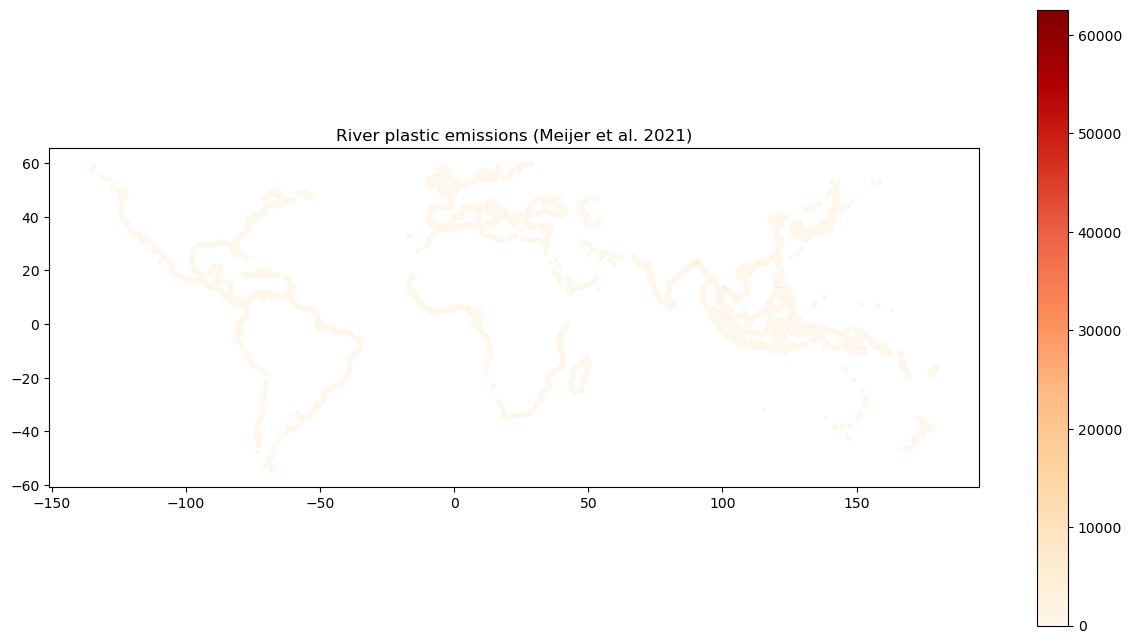

In [25]:
fig, ax = plt.subplots(figsize=(15, 8))
gdf.plot(ax=ax, column="dots_exten", 
         cmap="OrRd", 
         markersize=5, 
         legend=True)
ax.set_title("River plastic emissions (Meijer et al. 2021)")
plt.show()

In [26]:
coordinates = list(zip(gdf.geometry.y, gdf.geometry.x))
river_outfall = gdf.dots_exten

In [27]:
folder_Meijer = pd.DataFrame({
    "Latitude": [coord[0] for coord in coordinates],
    "Longitude": [coord[1] for coord in coordinates], 
    "river outfall": river_outfall
})

In [28]:
latitudes_folder  = np.array(folder_Meijer["Latitude"], dtype=float)
longitudes_folder = np.array(folder_Meijer["Longitude"], dtype=float)
outfall = np.array(folder_Meijer["river outfall"], dtype=float)


discharge_folder = list(zip(latitudes_folder, longitudes_folder, outfall))

lats_folder   = [p[0] for p in discharge_folder]
lons_folder   = [p[1] for p in discharge_folder]
# Format: (latitude, longitude, "Label")

# ──────────────────────────────────────────────────────────────────────────────

data = pd.read_csv('..\\0.1 MP abundance data collection\FINAL gridded concentrations.csv')
data.head()

latitudes_data  = np.array(data["Lat_center"], dtype=float)
longitudes_data = np.array(data["Lon_center"], dtype=float)

points_data = list(zip(latitudes_data, longitudes_data))
# Format: (latitude, longitude, "Label")

lats_data   = [p[0] for p in points_data]
lons_data   = [p[1] for p in points_data]


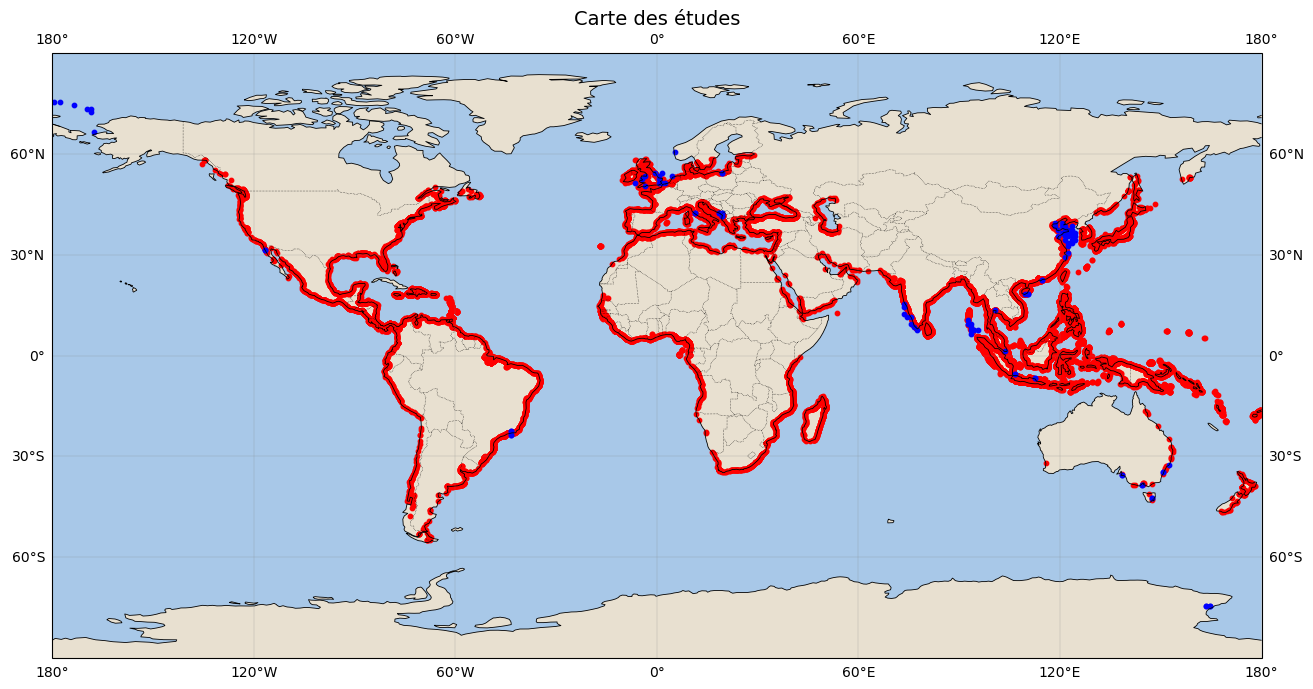

In [29]:
fig = plt.figure(figsize=(14, 7))
ax  = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

ax.set_global()
ax.add_feature(cfeature.LAND,       facecolor="#e8e0d0")
ax.add_feature(cfeature.OCEAN,      facecolor="#a8c8e8")
ax.add_feature(cfeature.COASTLINE,  linewidth=0.6)
ax.add_feature(cfeature.BORDERS,    linewidth=0.4, linestyle=":")
ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5)

ax.scatter(lons_folder, lats_folder, s=10, color="red", zorder=1, transform=ccrs.PlateCarree())
ax.scatter(lons_data, lats_data, s=10, color="blue", zorder=1, transform=ccrs.PlateCarree())

plt.title("Carte des études", fontsize=14)
plt.tight_layout()
plt.show()

### Data treatment

In [30]:
## Data treatment ## 

def compute_distances(lat, lon, lats, lons):
    """Computes distances in km using the Haversine formula"""
    R = 6378
    lat1, lon1, lat2, lon2 = np.radians(lat), np.radians(lon), np.radians(lats), np.radians(lons)
    dLat = (lat2-lat1)
    dLon = (lon2-lon1)
    d = 2*R*np.arcsin(np.sqrt((np.sin(dLat/2))**2 + np.cos(lat1) * np.cos(lat2) * (np.sin(dLon/2))**2))
    return d

coords     = np.array([(p[0], p[1]) for p in discharge_folder], dtype=float)

In [31]:
points_arr = np.array(discharge_folder)

In [32]:
def nearest_discharge(method, lat, lon, coords, points_array):
    """ Returns distance from sapling point to nearest river discharge point and its associated values. 4 ways to search for nearest point exist:
    nearest point - finds the smallest distance
    sum of 5 nearests - finds 5 smallest distances and does the sum of values for each columns, mean distance is considered
    100 km radius - finds the smallest distance and then sums all municipalities in a 100 km radius around the nearest one
    50 km radius - finds the smallest distance and then sums all municipalities in a 50 km radius around the nearest one
    Mean value over multiple river discharges were found to be not good indicators.
    """

    distances = compute_distances(lat, lon, coords[:, 0], coords[:, 1])
    distances = distances[np.isfinite(distances)]
    
    # Find closest point
    if method == "nearest point":
        idx_nearest = np.argmin(distances)
        nearest = points_array[idx_nearest]
        nearest = np.array(nearest, dtype=object)
        min_distance = distances[idx_nearest]
        return (min_distance, nearest[2])  # Return distance and parameters of nearest point
    
    if method == "sum of 5 nearests":
        idx_smallest_five = np.argpartition(distances, 5)[:5] # rearranges the indices so that the 5 smallest values are guaranteed to be in the first 5 positions of the result 
        nearby = points_array[idx_smallest_five]
        min_distances = distances[idx_smallest_five]
        nearby = np.nansum(nearby, axis=0)
        return (np.nanmean(min_distances, axis=0), nearby[2])
    
    if method == "100 km radius":
        idx_nearest = np.argmin(distances)
        nearest = points_array[idx_nearest]
        min_distance = distances[idx_nearest]
        # Vectorized distances from nearest point to all points
        distances_from_nearest = compute_distances(nearest[0], nearest[1], coords[:, 0], coords[:, 1])

        # All points within 100 km
        mask = distances_from_nearest <= 100
        nearby = points_array[mask]
        nearby = np.nansum(nearby, axis=0) + nearest
        return (min_distance, nearby[2])
    
    if method == "50 km radius":
        idx_nearest = np.argmin(distances)
        nearest = points_array[idx_nearest]
        min_distance = distances[idx_nearest]
        # Vectorized distances from nearest point to all points
        distances_from_nearest = compute_distances(nearest[0], nearest[1], coords[:, 0], coords[:, 1])

        # All points within 50 km
        mask = distances_from_nearest <= 50
        nearby = points_array[mask]
        nearby = np.nansum(nearby, axis=0) + nearest

        return (min_distance, nearby[2])

In [33]:
result_np = []
result_sum5 = []
result_100km = []
result_50km = []

for lat, lon in zip(lats_data, lons_data):
    output = nearest_discharge(method = "nearest point",lat = lat, lon = lon, coords = coords, points_array = points_arr)
    result_np.append(output)
    output = nearest_discharge(method = "sum of 5 nearests",lat = lat, lon = lon, coords = coords, points_array = points_arr)
    result_sum5.append(output)
    output = nearest_discharge(method = "100 km radius",lat = lat, lon = lon, coords = coords, points_array = points_arr)
    result_100km.append(output)
    output = nearest_discharge(method = "50 km radius",lat = lat, lon = lon, coords = coords, points_array = points_arr)
    result_50km.append(output)

df_np = pd.DataFrame(result_np[i] for i in range(len(result_np)))
df_np = pd.concat([df_np.drop(1, axis=1),df_np[1].apply(pd.Series)], axis=1)
df_np.columns = ['Distance Meijer nearest_point'] + ["River Input nearest_point"]


df_sum5 = pd.DataFrame(result_sum5[i] for i in range(len(result_sum5)))
df_sum5 = pd.concat([df_sum5.drop(1, axis=1),df_sum5[1].apply(pd.Series)], axis=1)
df_sum5.columns = ['Distance Meijer sum5'] + ["River Input sum5"]

df_100km = pd.DataFrame(result_100km[i] for i in range(len(result_100km)))
df_100km = pd.concat([df_100km.drop(1, axis=1),df_100km[1].apply(pd.Series)], axis=1)
df_100km.columns = ['Distance Meijer 100km'] + ["River Input 100km"]

df_50km = pd.DataFrame(result_50km[i] for i in range(len(result_50km)))
df_50km = pd.concat([df_50km.drop(1, axis=1),df_50km[1].apply(pd.Series)], axis=1)
df_50km.columns = ['Distance Meijer 50km'] + ["River Input 50km"]

In [34]:
output = pd.concat([df_np, df_sum5, df_100km, df_50km], axis=1)
output

,Distance Meijer nearest_point,River Input nearest_point,Distance Meijer sum5,River Input sum5,Distance Meijer 100km,River Input 100km,Distance Meijer 50km,River Input 50km
0,3118.552383,0.164904,3134.969381,1.821877,3118.552383,1.986781,3118.552383,1.668110
1,3114.909436,0.164904,3131.436347,1.821877,3114.909436,1.986781,3114.909436,1.668110
2,31.128224,0.108960,255.442513,1.120017,31.128224,0.424985,31.128224,0.424985
3,56.390061,0.202907,93.022879,5.169424,56.390061,5.261384,56.390061,5.261384
4,41.603844,0.167220,433.089777,0.776324,41.603844,0.334440,41.603844,0.334440
...,...,...,...,...,...,...,...,...
99,2244.880720,0.270531,2272.911283,2.128463,2244.880720,2.077609,2244.880720,2.077609
100,2217.593944,0.270531,2245.760224,2.128463,2217.593944,2.077609,2217.593944,2.077609
101,2405.610072,0.270531,2433.920100,2.128463,2405.610072,2.077609,2405.610072,2.077609
102,2608.788306,0.270531,2626.957064,3.500118,2608.788306,2.077609,2608.788306,2.077609


In [35]:
output_divided = output.copy()

# Remove infinities and zero values from distance denominators before normalization
keys = ['nearest_point', 'sum5', '100km', '50km']
for key in keys:
    dist = output_divided[f'Distance Meijer {key}'].replace({0: np.nan})
    output_divided[f'Input/Distance Meijer {key}'] = output_divided[f'River Input {key}']/dist


In [36]:
output_divided

,Distance Meijer nearest_point,River Input nearest_point,Distance Meijer sum5,River Input sum5,Distance Meijer 100km,River Input 100km,Distance Meijer 50km,River Input 50km,Input/Distance Meijer nearest_point,Input/Distance Meijer sum5,Input/Distance Meijer 100km,Input/Distance Meijer 50km
0,3118.552383,0.164904,3134.969381,1.821877,3118.552383,1.986781,3118.552383,1.668110,0.000053,0.000581,0.000637,0.000535
1,3114.909436,0.164904,3131.436347,1.821877,3114.909436,1.986781,3114.909436,1.668110,0.000053,0.000582,0.000638,0.000536
2,31.128224,0.108960,255.442513,1.120017,31.128224,0.424985,31.128224,0.424985,0.003500,0.004385,0.013653,0.013653
3,56.390061,0.202907,93.022879,5.169424,56.390061,5.261384,56.390061,5.261384,0.003598,0.055572,0.093303,0.093303
4,41.603844,0.167220,433.089777,0.776324,41.603844,0.334440,41.603844,0.334440,0.004019,0.001793,0.008039,0.008039
...,...,...,...,...,...,...,...,...,...,...,...,...
99,2244.880720,0.270531,2272.911283,2.128463,2244.880720,2.077609,2244.880720,2.077609,0.000121,0.000936,0.000925,0.000925
100,2217.593944,0.270531,2245.760224,2.128463,2217.593944,2.077609,2217.593944,2.077609,0.000122,0.000948,0.000937,0.000937
101,2405.610072,0.270531,2433.920100,2.128463,2405.610072,2.077609,2405.610072,2.077609,0.000112,0.000874,0.000864,0.000864
102,2608.788306,0.270531,2626.957064,3.500118,2608.788306,2.077609,2608.788306,2.077609,0.000104,0.001332,0.000796,0.000796


In [37]:
data_points_expended = pd.concat([data, output_divided], axis = 1)
data_points_expended.to_csv('outputs\River Discharge Meijer dataset.csv',index=False)

### Statistics

In [38]:
parameters = output_divided.keys()

n = len(parameters)
if n % 2 == 0: n = n//2
else: n = n//2 + 1


In [39]:
# Normalize data for statistics
data_points_copy = data_points_expended.copy()
cols_to_normalize = [
                     'MEAN MP stock (g/m2) in 2021',
                     *parameters]

scaler = MinMaxScaler()
data_points_copy[cols_to_normalize] = scaler.fit_transform(data_points_copy[cols_to_normalize])

# Divide fibers from fragments
data_points_fib = data_points_copy[data_points_copy["Shape"] == "Fibers"]
data_points_frg = data_points_copy[data_points_copy["Shape"] == "Fragments"]

In [40]:
spearman_results = []

# Fibers

for key in parameters:
    x = data_points_fib[key]
    y = data_points_fib["MEAN MP stock (g/m2) in 2021"]


    # Remove NaNs
    mask = np.isfinite(x) & np.isfinite(y) 

    spearman_stock = stats.spearmanr(x[mask], y[mask])
    spearman_results.append((f'{key} fibers stock', spearman_stock[0], spearman_stock[1]))


# Fragmanrts
for key in parameters:
    x = data_points_frg[key]
    y = data_points_frg["MEAN MP stock (g/m2) in 2021"]


    # Remove NaNs from both arrays
    mask = np.isfinite(x) & np.isfinite(y)

    spearman_stock = stats.spearmanr(x[mask], y[mask])
    spearman_results.append((f'{key} fragments stock', spearman_stock[0], spearman_stock[1]))


# Both
for key in parameters:
    x = data_points_copy[key]
    y = data_points_copy["MEAN MP stock (g/m2) in 2021"]

    # Remove NaNs from both arrays
    mask = np.isfinite(x) & np.isfinite(y)

    spearman_stock = stats.spearmanr(x[mask], y[mask])
    spearman_results.append((f'{key} both stock', spearman_stock[0], spearman_stock[1]))
    


In [41]:
results_stats = pd.DataFrame(spearman_results, columns=["Parameter", "Spearman Correlation", "Spearman p-value"])

c:\Users\nelad\miniforge3\envs\Rapport_env\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\nelad\miniforge3\envs\Rapport_env\Lib\site-packages\numpy\lib\_function_base_impl.py:2882: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]
C:\Users\nelad\AppData\Local\Temp\ipykernel_9264\3863203624.py:34: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axs[parameters_list.index(key) // 2, parameters_list.index(key) % 2].scatter(subset[key], subset["MEAN MP stock (g/m2) in 2021"], c=colors[i])


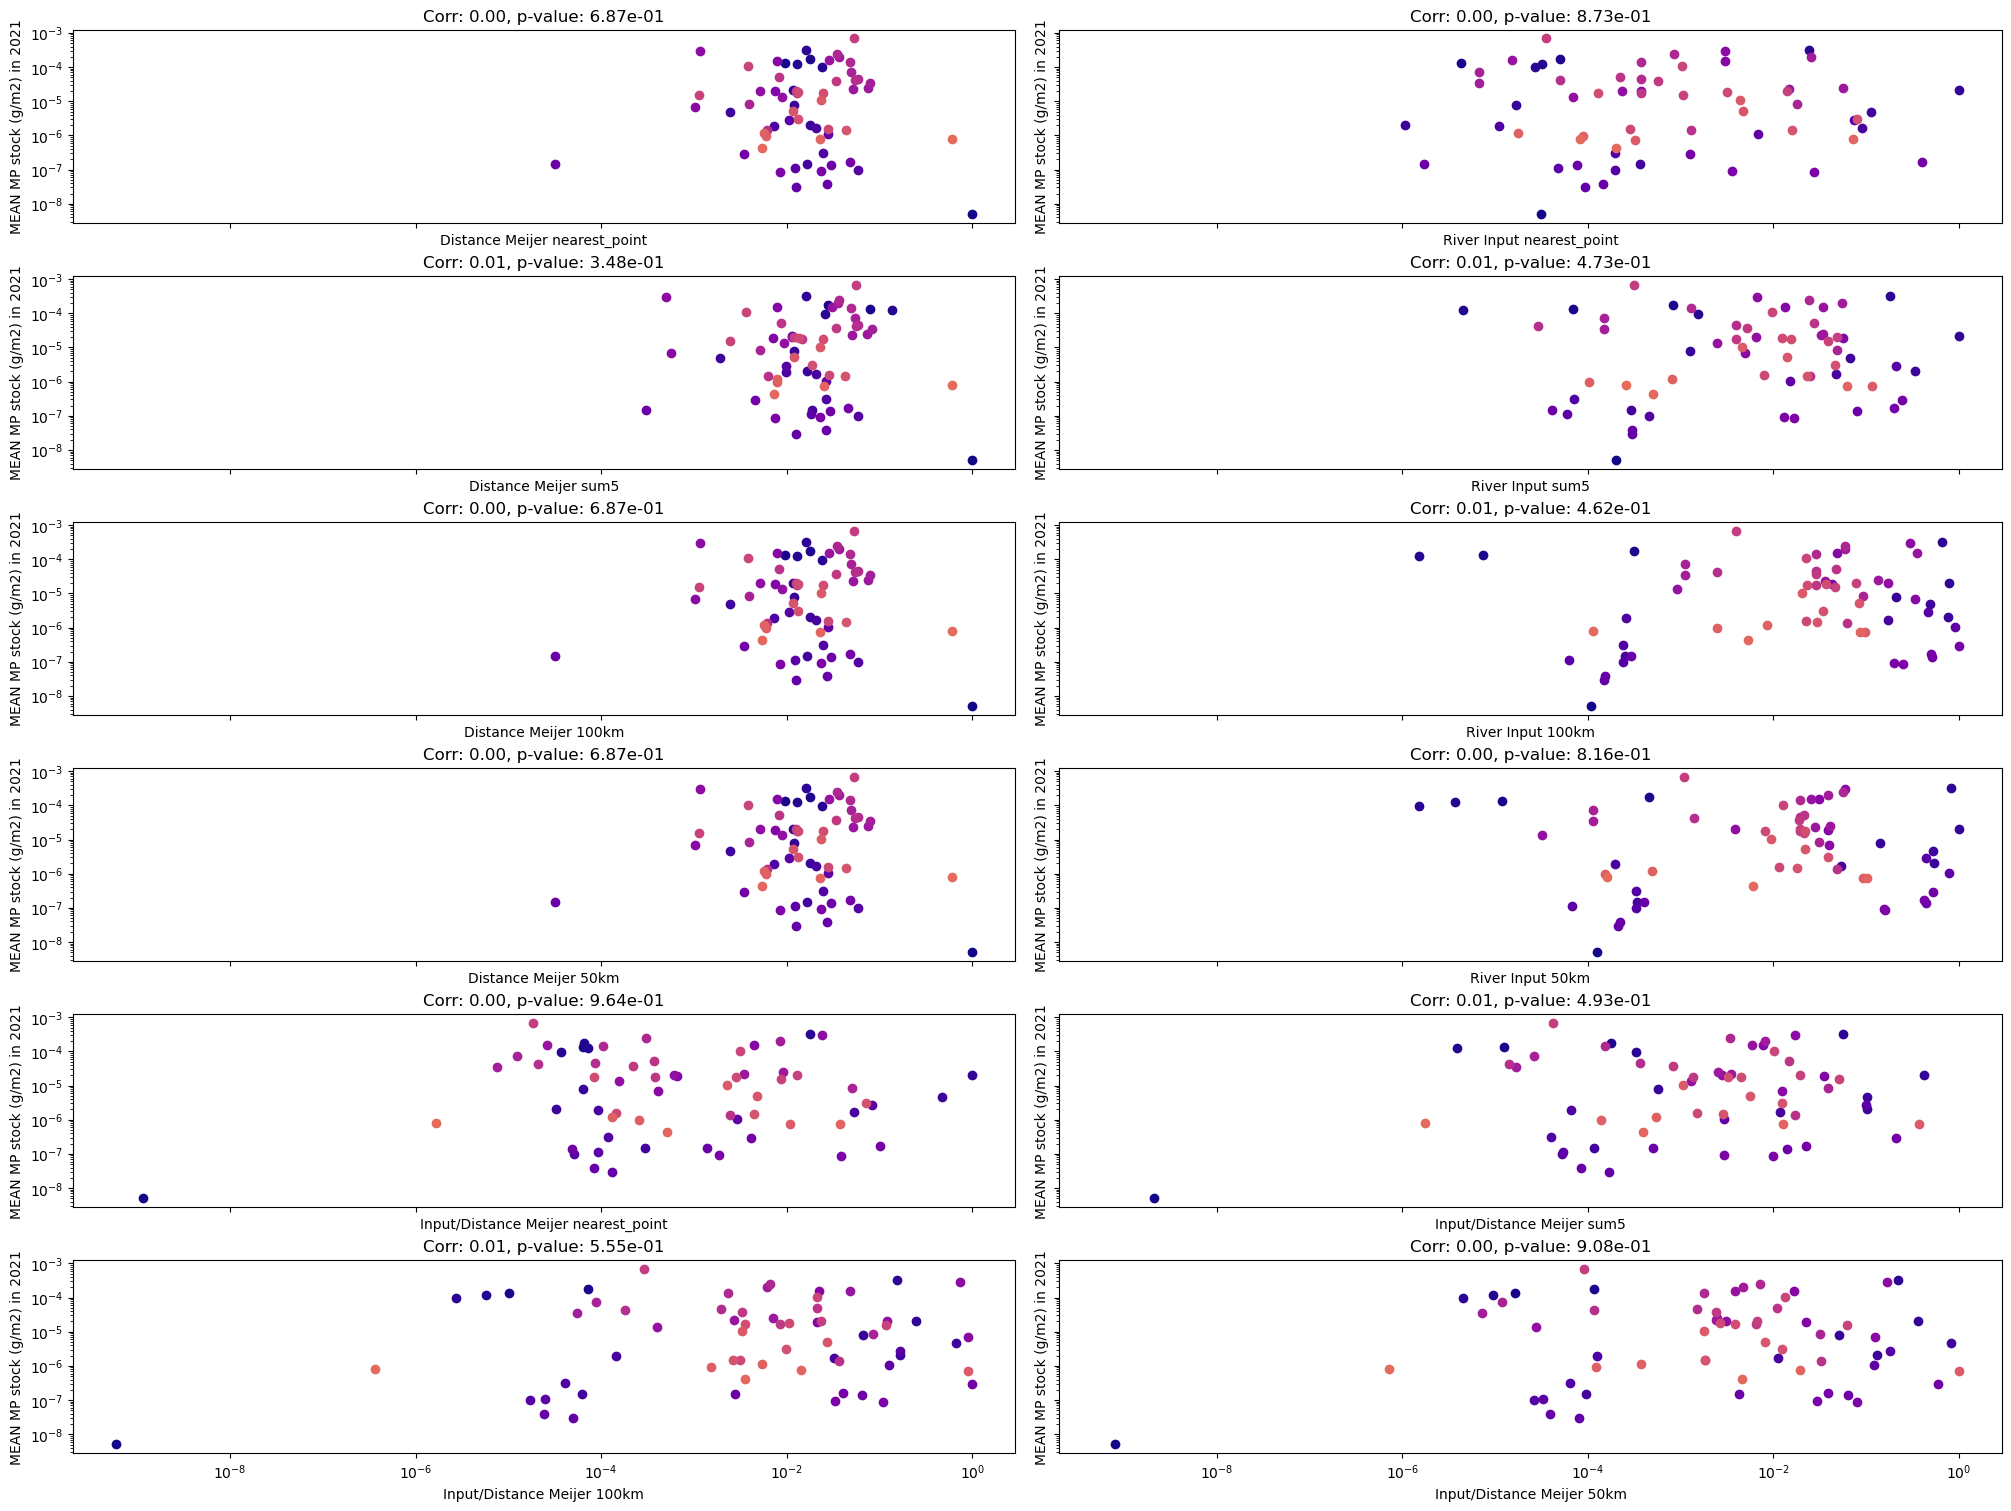

In [42]:
fig, axs = plt.subplots(n, 2, sharex=True, sharey=True, layout="constrained",figsize=(20, 15))
spearman_results = []

parameters_list = parameters.to_list()

cmap = plt.colormaps['plasma']
data_points_copy["Author"] = data_points_copy.index

colors = cmap(np.linspace(0, 1, len(data_points_copy["Author"].unique())))


data_points_fib["Author"] = data_points_fib.index

for key in parameters_list:
    x = data_points_fib[key]
    y = data_points_fib["MEAN MP stock (g/m2) in 2021"]

    # Remove NaNs from both arrays
    mask = np.isfinite(x) & np.isfinite(y)
    x_clean = x[mask]
    y_clean = y[mask]

    pearson = stats.pearsonr(x_clean, y_clean)
    spearman = stats.spearmanr(x_clean, y_clean)
    kendall = stats.kendalltau(x_clean, y_clean)
    spearman_results.append((spearman[0], spearman[1]))

    linreg = stats.linregress(np.log10(x_clean), np.log10(y_clean))
    
    for i, author in enumerate(data_points_fib["Author"].unique()):
        
        subset = data_points_fib[data_points_fib["Author"] == author]
        
        axs[parameters_list.index(key) // 2, parameters_list.index(key) % 2].scatter(subset[key], subset["MEAN MP stock (g/m2) in 2021"], c=colors[i])
        axs[parameters_list.index(key) // 2, parameters_list.index(key) % 2].set_xlabel(key)
        axs[parameters_list.index(key) // 2, parameters_list.index(key) % 2].set_ylabel("MEAN MP stock (g/m2) in 2021")
        axs[parameters_list.index(key) // 2, parameters_list.index(key) % 2].set_title(f"Corr: {spearman[0]**2:.2f}, p-value: {spearman[1]:.2e}")

plt.xscale("log")
plt.yscale("log")